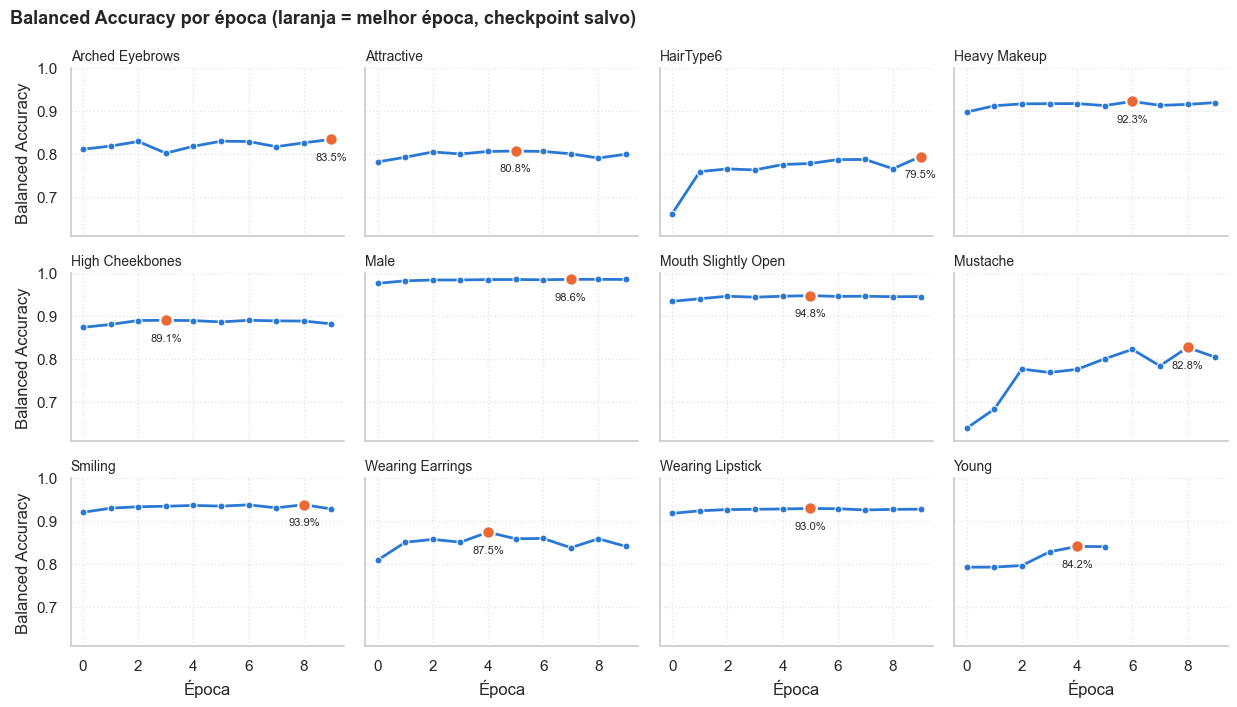

In [1]:
import os
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", font="sans-serif")

logs_dir = "logs"

latest = {}
for file in os.listdir(logs_dir):
    if file.endswith("_metrics.csv"):
        concept, run_id = file.removeprefix("celebahq_").removesuffix("_metrics.csv").split("_rn18_")
        if concept not in latest or run_id > latest[concept][0]:
            latest[concept] = (run_id, file)

dataframes = []
for concept, (run_id, file) in latest.items():
    df = pd.read_csv(os.path.join(logs_dir, file))
    df["Modelo"] = concept
    dataframes.append(df)

full_df = pd.concat(dataframes, ignore_index=True)
full_df = full_df.sort_values(by=["Modelo", "epoch"])

g = sns.relplot(
    data=full_df,
    x="epoch",
    y="bal_acc",
    col="Modelo",
    col_wrap=4,
    kind="line",
    marker="o",
    linewidth=2,
    markersize=5,
    color="#2a78d6",
    height=2.4,
    aspect=1.3,
    facet_kws=dict(sharey=True, sharex=True),
)

for concept, ax in g.axes_dict.items():
    d = full_df[full_df["Modelo"] == concept]
    best = d.loc[d["bal_acc"].idxmax()]
    ax.plot(best["epoch"], best["bal_acc"], "o", markersize=9,
            color="#eb6834", markeredgecolor="white", markeredgewidth=1.5, zorder=3)
    ax.annotate(f"{best['bal_acc']:.1%}", (best["epoch"], best["bal_acc"]),
                textcoords="offset points", xytext=(0, -15), ha="center", fontsize=8)

for concept, ax in g.axes_dict.items():
    ax.set_title("")                                             # apaga "Modelo = ..."
    ax.set_title(concept.replace("_", " "), loc="left", fontsize=10)
g.set_axis_labels("Época", "Balanced Accuracy")
min_acc = full_df["bal_acc"].min()
max_acc = full_df["bal_acc"].max()
g.set(ylim=(max(0, min_acc - 0.03), min(1.0, max_acc + 0.02)))
for ax in g.axes.flat:
    ax.grid(True, linestyle=":", alpha=0.5)

g.figure.suptitle("Balanced Accuracy por época (laranja = melhor época, checkpoint salvo)",
                  x=0.01, ha="left", fontsize=13, fontweight="bold")
g.tight_layout()
plt.show()

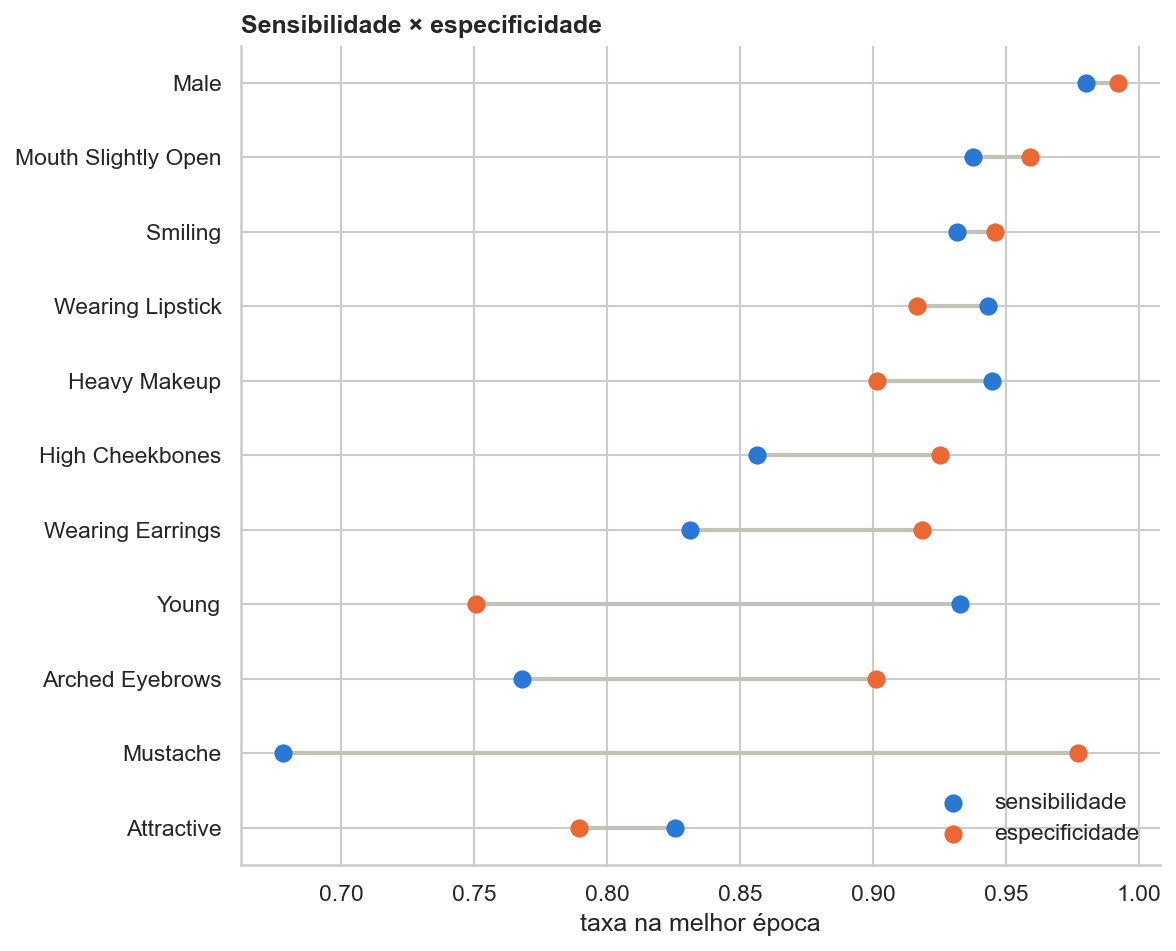

In [2]:
best = full_df.loc[full_df.groupby("Modelo")["bal_acc"].idxmax()]
binary = best.dropna(subset=["sens", "spec"]).sort_values("bal_acc")

fig, ax = plt.subplots(figsize=(8, 0.5 * len(binary) + 1), dpi=150)
for y, (_, r) in enumerate(binary.iterrows()):
    ax.plot([r["spec"], r["sens"]], [y, y], color="#c3c2b7", linewidth=2, zorder=1)
ax.scatter(binary["sens"], range(len(binary)), color="#2a78d6", s=60, label="sensibilidade", zorder=2)
ax.scatter(binary["spec"], range(len(binary)), color="#eb6834", s=60, label="especificidade", zorder=2)
ax.set_yticks(range(len(binary)), binary["Modelo"].str.replace("_", " "))
ax.set_xlabel("taxa na melhor época")
ax.set_title("Sensibilidade × especificidade",
             loc="left", fontweight="bold")
ax.legend(frameon=False, loc="lower right")
sns.despine()
plt.tight_layout(); plt.show()

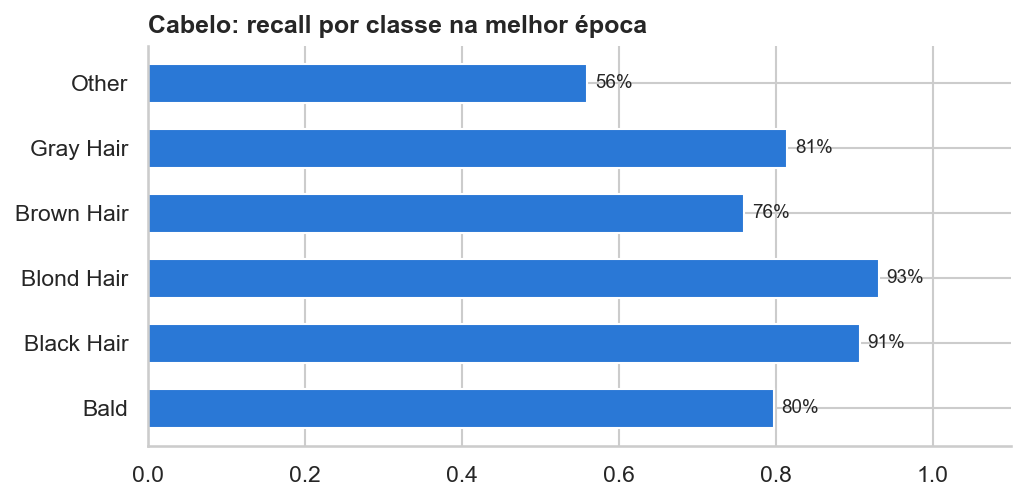

In [3]:
hair = best[best["Modelo"] == "HairType6"].iloc[0]
cols = [c for c in full_df.columns if c.startswith("recall_")]
names = [c.removeprefix("recall_").replace("_", " ") for c in cols]

fig, ax = plt.subplots(figsize=(7, 3.5), dpi=150)
ax.barh(names, hair[cols], color="#2a78d6", height=0.6)
for y, v in enumerate(hair[cols]):
    ax.text(v + 0.01, y, f"{v:.0%}", va="center", fontsize=9)
ax.set_xlim(0, 1.1)
ax.set_title("Cabelo: recall por classe na melhor época", loc="left", fontweight="bold")
sns.despine()
plt.tight_layout(); plt.show()

In [4]:
import os
import torch
from cbae.config import CONCEPTS, CLASSIFIER_FILES, N_CLASSES, CKPT_DIR, THRESHOLD
from cbae.stylegan2 import load_stylegan2
from cbae.suppseudolabeler import SupPseudoLabeler, load_classifier

avail = [k for k, f in enumerate(CLASSIFIER_FILES) if os.path.exists(os.path.join(CKPT_DIR, f))]
names = ["Hair" if N_CLASSES[k] > 2 else CONCEPTS[k][1] for k in avail]
M = SupPseudoLabeler([load_classifier(CLASSIFIER_FILES[k], N_CLASSES[k]) for k in avail]).to("cuda").eval()
G = load_stylegan2()

N_BATCHES, B = 64, 16
rows, samples = [], None
torch.manual_seed(0)
with torch.no_grad():
    for b in range(N_BATCHES):
        z = torch.randn(B, G.z_dim, device="cuda")
        x = G.synthesis(G.mapping(z, None, truncation_psi=1.0), noise_mode="const")
        preds, confs = M.hard(x)
        if samples is None:
            samples = (x[:8].cpu(), [p[:8].cpu() for p in preds], [c[:8].cpu() for c in confs])
        for j, k in enumerate(avail):
            for p, c in zip(preds[j].tolist(), confs[j].tolist()):
                rows.append(dict(Conceito=names[j], classe=CONCEPTS[k][p], conf=c, th=THRESHOLD[k]))

conf_df = pd.DataFrame(rows)
conf_df["usado"] = conf_df["conf"] >= conf_df["th"]

d:\Doutorado\modelos_imagens\cbae_stylegan2\torch_utils\ops\conv2d_gradfix.py:14: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version
d:\Doutorado\modelos_imagens\cbae_stylegan2\cbae\cbae_compat.py:39: RuntimeWarning: ops customizadas do StyleGAN desativadas (bias_act, upfirdn2d, filtered_lrelu); usando implementacao de referencia (mais lenta).
  warnings.warn(
d:\Doutorado\modelos_imagens\cbae_stylegan2\cbae\cbae_compat.py:64: RuntimeWarning: synthesis forcada para fp32 nas resolucoes 32, 64, 128, 256 (ops em modo referencia estouram em fp16).
  warnings.warn(


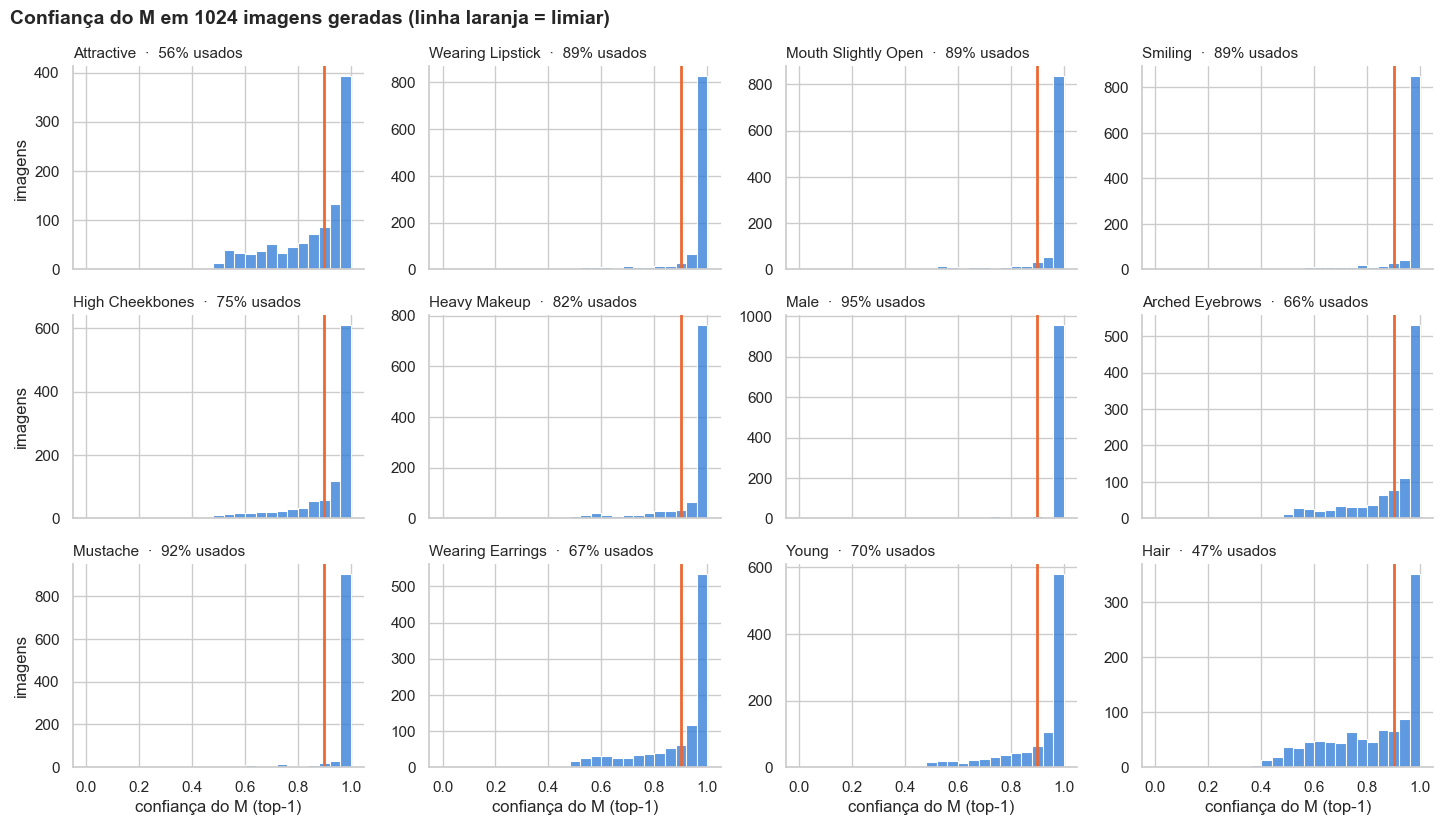

In [5]:
g = sns.displot(conf_df, x="conf", col="Conceito", col_wrap=4, bins=25, binrange=(0, 1),
                color="#2a78d6", height=2.8, aspect=1.3, facet_kws=dict(sharey=False))
for concept, ax in g.axes_dict.items():
    d = conf_df[conf_df["Conceito"] == concept]
    ax.axvline(d["th"].iloc[0], color="#eb6834", linewidth=2)
    ax.set_title("")
    ax.set_title(f"{concept}  ·  {d['usado'].mean():.0%} usados", loc="left", fontsize=11)
g.set_axis_labels("confiança do M (top-1)", "imagens")
g.figure.suptitle("Confiança do M em 1024 imagens geradas (linha laranja = limiar)",
                  x=0.01, ha="left", fontsize=14, fontweight="bold")
g.tight_layout(); plt.show()

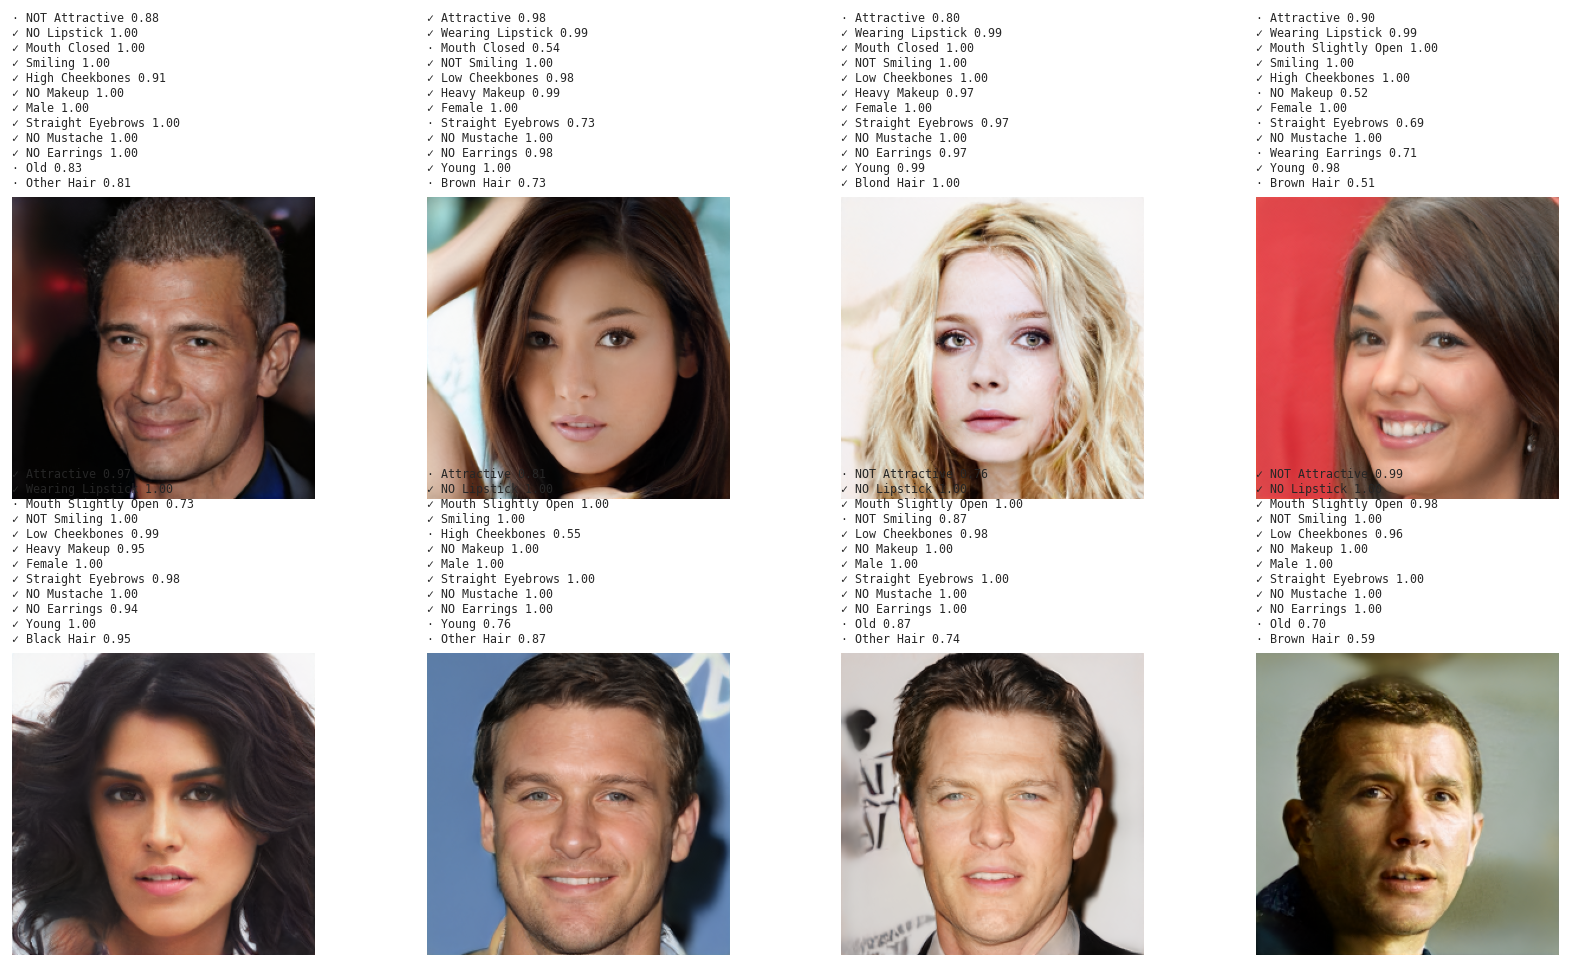

In [6]:
x8, p8, c8 = samples
fig, axes = plt.subplots(2, 4, figsize=(14, 8), dpi=120)
for i, ax in enumerate(axes.flat):
    ax.imshow((x8[i].permute(1, 2, 0) * 0.5 + 0.5).clamp(0, 1))
    ax.axis("off")
    lines = [f"{'✓' if c8[j][i] >= THRESHOLD[k] else '·'} {CONCEPTS[k][p8[j][i]]} {c8[j][i]:.2f}"
             for j, k in enumerate(avail)]
    ax.set_title("\n".join(lines), fontsize=7, loc="left", family="monospace")
plt.tight_layout(); plt.show()